In [2]:
# Imports
import gymnasium as gym
import numpy as np

 Observation space: Discrete(500)
 Action space: Discrete(6)


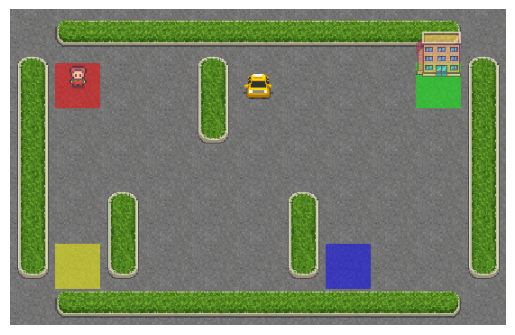

In [3]:
# Create and display the environment
taxi_env = gym.make("Taxi-v3", render_mode="rgb_array")

print(" Observation space:", taxi_env.observation_space)
print(" Action space:", taxi_env.action_space)

taxi_env.reset()
frame = taxi_env.render()

# Display the rendered frame
import matplotlib.pyplot as plt
plt.imshow(frame)
plt.axis('off')
plt.show()

## Goal

Find the optimal Q-values for each state-action pair. 

Start by initializing $Q(s, a) = 0$ for all $s$ and $a$ 

In [4]:
def initialize_q_table(env):
    """Initialize the Q-table with zeros."""
    return np.zeros((env.observation_space.n, env.action_space.n))

## $\epsilon$ - greedy policy

A policy that selects a random action with probaility $\epsilon$ and with probaility $1 - \epsilon$ selects the action which maximizes the Q-value from a given state.

\begin{equation}
a = argmax_{a} Q(s,a)
\end{equation}

In [15]:
# taxi_env.reset()

new_state, reward, terminated, truncated, _ = taxi_env.step(4)

print("New state:", new_state)
print("Reward:", reward)
print("Terminated:", terminated)

New state: 81
Reward: -10
Terminated: False


## Q-learning algorithm

Update rule is given by

\begin{equation}
Q (S_t, A_t) \leftarrow Q(S_t, A_t) + \gamma \left( r_{t+1} + max_a Q(S_{t+1}, a) - Q(S_t, A_t) \right)
\end{equation}

In [16]:
def train(env, q_table, num_episodes=200, max_steps_per_episode=200, learning_rate=0.1, discount_factor=0.99, max_exploration_rate=1.0, min_exploration_rate=0.5, exploration_decay_rate=0.001):
    """Train the agent using the Q-learning algorithm."""
    
    # Loop through episodes
    for episode in range(num_episodes):
        # Compute the exploration rate for this episode
        exploration_rate = min_exploration_rate + (max_exploration_rate - min_exploration_rate) * np.exp(-exploration_decay_rate * episode)

        # Reset the environment and get the initial state
        state, _ = env.reset()

        print(f"Episode {episode + 1}/{num_episodes}")
        
        # Go through each step of the episode
        for step in range(max_steps_per_episode):
            # Choose an action using epsilon-greedy strategy
            if np.random.uniform(0, 1) < exploration_rate:
                action = env.action_space.sample()  # Explore: select a random action
            else:
                action = np.argmax(q_table[state])  # Exploit: select the action with max Q-value
            
            # Take the action and observe the new state and reward
            new_state, reward, terminated, truncated, _ = env.step(action)
            
            # Update the Q-table using the Q-learning formula
            q_table[state, action] = q_table[state, action] + learning_rate * (reward + discount_factor * np.max(q_table[new_state, :]) - q_table[state, action])

            # Break the loop if the episode is done
            # TODO: What's the difference between terminated and truncated? Should we break if either is True?
            # Answer: In the context of OpenAI Gym environments, "terminated" typically indicates that the episode has ended due to a specific condition being met (e.g., reaching a goal state, falling into a hole, etc.), 
            # while "truncated" indicates that the episode has been cut off due to reaching a maximum number of steps or time limit. 
            # In most cases, you would want to break the loop if either "terminated" or "truncated" is True, as both conditions signify the end of an episode.
            if terminated or truncated:
                break

            # Update the state
            state = new_state
    
    return q_table

In [18]:
## Train the agent using the Q-learning algorithm
num_episodes = 200
max_steps_per_episode = 200
learning_rate = 0.1
discount_factor = 0.99
max_exploration_rate = 1.0
min_exploration_rate = 0.1
exploration_decay_rate = 0.001

q_table = initialize_q_table(taxi_env)
trained_q_table = train(taxi_env, q_table, num_episodes, max_steps_per_episode, learning_rate, discount_factor, max_exploration_rate, min_exploration_rate, exploration_decay_rate)

print("Trained Q-table shape:", trained_q_table.shape)

Episode 1/200
Episode 2/200
Episode 3/200
Episode 4/200
Episode 5/200
Episode 6/200
Episode 7/200
Episode 8/200
Episode 9/200
Episode 10/200
Episode 11/200
Episode 12/200
Episode 13/200
Episode 14/200
Episode 15/200
Episode 16/200
Episode 17/200
Episode 18/200
Episode 19/200
Episode 20/200
Episode 21/200
Episode 22/200
Episode 23/200
Episode 24/200
Episode 25/200
Episode 26/200
Episode 27/200
Episode 28/200
Episode 29/200
Episode 30/200
Episode 31/200
Episode 32/200
Episode 33/200
Episode 34/200
Episode 35/200
Episode 36/200
Episode 37/200
Episode 38/200
Episode 39/200
Episode 40/200
Episode 41/200
Episode 42/200
Episode 43/200
Episode 44/200
Episode 45/200
Episode 46/200
Episode 47/200
Episode 48/200
Episode 49/200
Episode 50/200
Episode 51/200
Episode 52/200
Episode 53/200
Episode 54/200
Episode 55/200
Episode 56/200
Episode 57/200
Episode 58/200
Episode 59/200
Episode 60/200
Episode 61/200
Episode 62/200
Episode 63/200
Episode 64/200
Episode 65/200
Episode 66/200
Episode 67/200
Epis

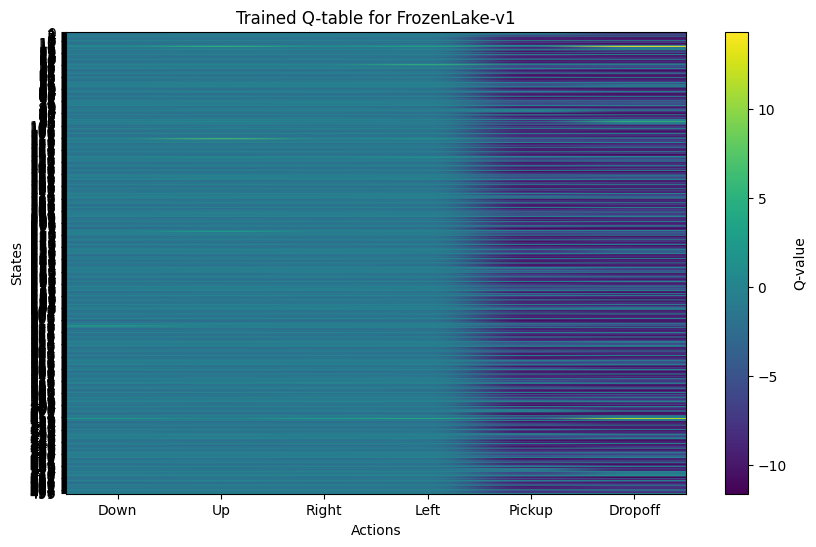

In [21]:
# Visualize the trained Q-table
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.imshow(trained_q_table, cmap='viridis', aspect='auto')
plt.colorbar(label='Q-value')
plt.title('Trained Q-table for FrozenLake-v1')
plt.xlabel('Actions')
plt.ylabel('States')
plt.xticks(ticks=np.arange(taxi_env.action_space.n), labels=['Down',  'Up', 'Right', 'Left', 'Pickup', 'Dropoff'])
plt.yticks(ticks=np.arange(taxi_env.observation_space.n))
plt.show()  

In [25]:
from tqdm import tqdm

def evaluate_agent(env, max_steps, n_eval_episodes, Q, seed):
    """
    Evaluate the agent for ``n_eval_episodes`` episodes and returns average reward and std of reward.
    :param env: The evaluation environment
    :param n_eval_episodes: Number of episode to evaluate the agent
    :param Q: The Q-table
    :param seed: The evaluation seed array (for taxi-v3)
    """
    episode_rewards = []
    for episode in tqdm(range(n_eval_episodes)):
        if seed:
            state, info = env.reset(seed=seed[episode])
        else:
            state, info = env.reset()
        step = 0
        truncated = False
        terminated = False
        total_rewards_ep = 0

        for step in range(max_steps):
            # Take the action (index) that have the maximum expected future reward given that state
            action = np.argmax(Q[state, :])
            new_state, reward, terminated, truncated, info = env.step(action)
            total_rewards_ep += reward

            if terminated or truncated:
                break
            state = new_state
        episode_rewards.append(total_rewards_ep)
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)

    return mean_reward, std_reward

In [26]:
# Evaluate our Agent
n_eval_episodes = 100
max_steps = 200
eval_seed = [42 + i for i in range(n_eval_episodes)]

mean_reward, std_reward = evaluate_agent(taxi_env, max_steps, n_eval_episodes, trained_q_table, eval_seed)
print(f"Mean_reward={mean_reward:.2f} +/- {std_reward:.2f}")

100%|██████████| 100/100 [00:00<00:00, 1135.84it/s]

Mean_reward=-200.00 +/- 0.00
